In [3]:
cd ../codes/utils/logs

/home/ec2-user/Brain2VLM/codes/utils/logs


/home/ec2-user/Brain2VLM/.venv/lib/python3.11/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


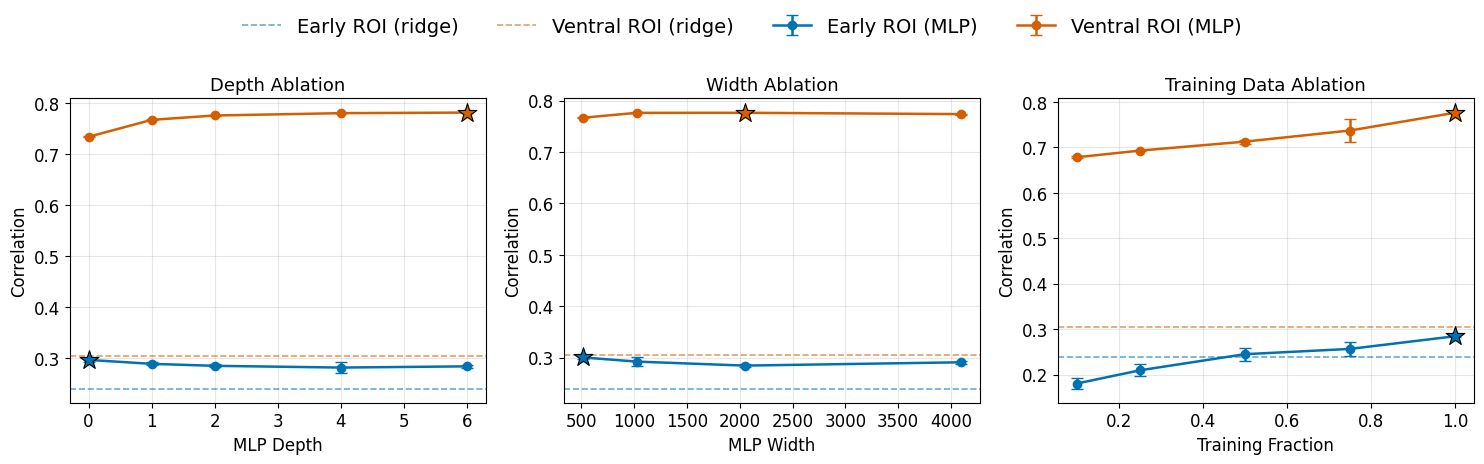

Saved mlp_ablation_cvpr.svg / .png


In [7]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ── Paths ────────────────────────────────────────────────────────────────────
LOG_DIR = Path(".")

FILE_MAP = {
    ("init_latent", "depth"): LOG_DIR / "run_latent_depth_ablation.txt",
    ("c",           "depth"): LOG_DIR / "run_c_depth_ablation.txt",
    ("init_latent", "width"): LOG_DIR / "run_latent_width_ablation.txt",
    ("c",           "width"): LOG_DIR / "run_c_width_ablation.txt",
    ("init_latent", "frac"):  LOG_DIR / "run_latent_frac_ablation.txt",
    ("c",           "frac"):  LOG_DIR / "run_c_frac_ablation.txt",
}

REGRESSION_FILES = {
    "init_latent": LOG_DIR / "run_latent_regression.txt",
    "c":           LOG_DIR / "run_c_regression.txt",
}

# ── Parsers ───────────────────────────────────────────────────────────────────
def parse_ablation_file(fpath, ablation_type, target):
    text = fpath.read_text()
    header_pat = re.compile(r"(?:DEPTH|WIDTH|FRAC)=([0-9.]+)\s+SEED=(\d+)")
    corr_pat   = re.compile(r"Final correlation:\s*([0-9.]+)")
    records = []
    for header, corr in zip(header_pat.finditer(text), corr_pat.finditer(text)):
        records.append({
            "target":      target,
            "ablation":    ablation_type,
            ablation_type: float(header.group(1)),
            "seed":        int(header.group(2)),
            "corr":        float(corr.group(1)),
        })
    return records


def parse_regression_file(fpath):
    text = fpath.read_text()
    m = re.search(r"Prediction accuracy is:\s*([0-9.]+)", text)
    if not m:
        raise ValueError(f"No 'Prediction accuracy' found in {fpath}")
    return float(m.group(1))


# ── Build dataframe ──────────────────────────────────────────────────────────
records = []
for (target, abl_type), fpath in FILE_MAP.items():
    records.extend(parse_ablation_file(fpath, abl_type, target))

df = pd.DataFrame(records)

regression_baselines = {
    target: parse_regression_file(fpath)
    for target, fpath in REGRESSION_FILES.items()
}


# ── Summary ──────────────────────────────────────────────────────────────────
def summarise(df, ablation_type):
    return (
        df[df.ablation == ablation_type]
        .groupby(["target", ablation_type])["corr"]
        .agg(mean_corr="mean", std_corr="std")
        .reset_index()
    )

depth_df = summarise(df, "depth")
width_df = summarise(df, "width")
frac_df  = summarise(df, "frac")


# ── Plot ─────────────────────────────────────────────────────────────────────
COLORS = {
    "init_latent": "#0072B2",
    "c":           "#D55E00",
}

LABELS = {
    "init_latent": "Early ROI",
    "c":           "Ventral ROI",
}

plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "svg.fonttype": "none",
})

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))


def plot_two_lines(ax, summary_df, x_col, title, xlabel):
    for target in ["init_latent", "c"]:
        sub = summary_df[summary_df.target == target].sort_values(x_col)
        if sub.empty:
            continue

        color = COLORS[target]

        # MLP curve
        ax.errorbar(
            sub[x_col], sub.mean_corr, yerr=sub.std_corr,
            marker="o", markersize=6, capsize=4,
            color=color, linewidth=1.8,
            label=f"{LABELS[target]} (MLP)",
        )

        # Best point
        best_idx = sub.mean_corr.idxmax()
        ax.scatter(
            sub.loc[best_idx, x_col], sub.loc[best_idx, "mean_corr"],
            s=200, marker="*", color=color,
            edgecolor="black", linewidth=0.8, zorder=10,
        )

        # Ridge baseline
        baseline = regression_baselines[target]
        ax.axhline(
            baseline, color=color, linestyle="--",
            linewidth=1.2, alpha=0.6,
            label=f"{LABELS[target]} (ridge)",
        )

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Correlation")
    ax.grid(True, alpha=0.3)


plot_two_lines(axes[0], depth_df, "depth", "Depth Ablation",        "MLP Depth")
plot_two_lines(axes[1], width_df, "width", "Width Ablation",        "MLP Width")
plot_two_lines(axes[2], frac_df,  "frac",  "Training Data Ablation","Training Fraction")


# ── Global legend (single, deduplicated) ──────────────────────────────────────
handles, labels = axes[0].get_legend_handles_labels()
by_label = dict(zip(labels, handles))

fig.legend(
    by_label.values(),
    by_label.keys(),
    loc="upper center",
    ncol=4,
    fontsize=14,
    frameon=False,
    bbox_to_anchor=(0.5, 1.05)
)

# ── Layout ───────────────────────────────────────────────────────────────────
plt.tight_layout(rect=[0, 0, 1, 0.92])

plt.savefig("mlp_ablation_cvpr.svg", bbox_inches="tight")
# plt.savefig("mlp_ablation_cvpr.png", dpi=150, bbox_inches="tight")
plt.show()

print("Saved mlp_ablation_cvpr.svg / .png")